# Branched Signature Kernel Model for single trajectory rough nonlinear ODEs

## Problem Introduction

The Problem is:

$$
\begin{align*}
&u''(x)+k_1u'(x)+k_2u(x)+k_3u^3(x)=f(x)\\
&u(0)=a\\
&u'(0)=b
\end{align*}
$$
with constants $k_1,k_2,k_2,a,$ and $b$.


## Imports

In [5]:
# Cell 1 - installs + clone
!pip install stochastic
!pip install --upgrade 'stochastic>=0.6.0'

!pip install --quiet torch torchvision jax jaxlib keras_sig numpy matplotlib scipy pytorch-minimize
!git clone https://github.com/CharliePyle4/BSK_ODE.git /content/BSK_ODE 2>/dev/null || git -C /content/BSK_ODE pull

# Cell 2 - import
import sys
sys.path.insert(0, '/content/BSK_ODE')
from bsk_ode.Duffing_Oscillator import *
print("Using device:", device, "torch", torch.__version__)


  Using cached stochastic-0.6.0-py3-none-any.whl.metadata (6.0 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 130.6 MB/s eta 0:00:0000:010:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: stochastic
    Found existing installation: stochastic 0.4.0
    Uninstalling stochastic-0.4.0:
      Successfully uninstalled stochastic-0.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 re

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 140.9 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
stochastic 0.6.0 requires numpy<2.0,>=1.17, but you have numpy 2.4.6 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.6 which is incompatible.
Already up to date.
Using device: cuda torch 2.11.0+cu128
Using device: cuda torch 2.11.0+cu128
Using device: cuda torch 2.11.0+cu128


# Problem Setup

In [6]:
# === Problem setup ===
# Interval and boundary conditions
a = 0.0       # start of x interval
b = 1      # end of x interval
ya = 0.0      # u(0)
ypa = 1.0     # u'(0)

# Operator coefficients
k1 = 5.0     # damping
k2 = 10.0      # stiffness
k3 = 10.0      # cubic

# Grid (number of points) and forcing
N = 1000
x = torch.linspace(a, b, N, device=device)
hurst = .4  #Forcing Hurst Parameter


TRAIN_FRAC = 0.8  # fraction of grid points used for training



# === Train / Test Split ===
N_train = int(N * TRAIN_FRAC)
N_test  = N - N_train

# Training slice: first N_train points (contiguous, causal split)
x_train = x[:N_train]
x_test  = x[N_train:]

print(f"Total grid points : {N}")
print(f"Train points      : {N_train}  (x in [{float(x_train[0]):.3f}, {float(x_train[-1]):.3f}])")
print(f"Test  points      : {N_test}   (x in [{float(x_test[0]):.3f},  {float(x_test[-1]):.3f}])")


Total grid points : 1000
Train points      : 800  (x in [0.000, 0.800])
Test  points      : 200   (x in [0.801,  1.000])


# Parameter Choices, and model hyperparameters

In [7]:
# Signature parameters
SIG_DEPTH      = 2         #Signature Depth

# Signature Normalization parameters
NORM_SCHEME = "col_robust"   # "none" or "col_zscore", "row_zscore" "row_robust", "col_robust", "row_unit", etc...
NORM_KWARGS = {}             #


#Kernel Parameters
KERNEL_TYPE = "rbf"   # or "linear"
rbf_sigma      = 1        #Rbf kernel sigma parameter, ignored if linear is chosen


#Neural Network Architecture
#HIDDEN_DIMS    = (512, 256, 128, 64, 32, 16)  
HIDDEN_DIMS    = (2, 4, 8, 4, 2)  #Hidden network layers: any tuple/list of ints. Ex: (512, 256, 128, 64, 32, 16)
ACTIVATION_CLS = nn.Tanh    #Activation, for example nn.Tanh, nn.ReLU, nn.GELU, custom class
extensions     = 1          #Number of path extensions to learn
num_snapshots  = 10          #number of training snapshots to visualize

#Adam Training
ADAM_ITERS     = 2000        #Adam Epochs
ADAM_LR        = 3e-4       #Adam Learning rate
ADAM_lambda_model   = 10        #ODE loss weight
ADAM_lambda_shuffle = 1e-3       #Shuffle Loss Weight


# Adam LR scheduler (ReduceLROnPlateau)
ADAM_USE_SCHEDULER = True   # or False
ADAM_SCHED_FACTOR   = 0.5   # new_lr = factor * old_lr
ADAM_SCHED_PATIENCE = 300    # epochs without improvement before LR drop


#Beta Optimization
BETA_OPTIMIZATION_METHOD = "l-bfgs"
BETA_MAX_ITERATIONS = 200

BETA_SOLVE_EVERY = 100 # run LBFGS only every ___ Adam steps
BETA_MIN_ITERATIONS = 50 # minimum LBFGS iters early in training
BETA_RAMP_PORTION = 0.25 # fraction of Adam iters to ramp from min -> max, ramps linearly.

""" For default settings
# New: throttling + ramp-up (disable both)
BETA_SOLVE_EVERY    = 1     # solve every Adam step
BETA_MIN_ITERATIONS = BETA_MAX_ITERATIONS  # no ramp, always full iters
BETA_RAMP_PORTION   = 1.0   # or any value; has no effect when min=max
"""

#Testing:
RETRAIN_EVERY = 5



# Run Solvers and Train Models

In [8]:
# === Run experiment on TRAINING data only ===
print("Running IVP and signature-kernel solvers on TRAINING split...\n")

# 1) Generate forcing on full grid, then slice to train
forcing = f_forcing_fbm(x, hurst)
forcing_train = forcing[:N_train]

print("solving ivp reference (train)")
x_ref_train, u_ref_train = solve_duffing_ivp(
    x_grid=x_train,
    forcing_torch=forcing_train,
    a=float(x_train[0]), b=float(x_train[-1]),
    ya=ya, ypa=ypa,
    k1=k1, k2=k2, k3=k3
)

# ── Non-branched ──
print("\nsolving non-branched, method 1")
u_nb_m1, f_pred_nb_m1 = solve_signature_kernel_non_branched_method1(
    x=x_train, f=forcing_train,
    k1=k1, k2=k2, k3=k3, ua=ya, upa=ypa,
    depth=SIG_DEPTH, rbf_sigma=rbf_sigma,
    beta_opt_method=BETA_OPTIMIZATION_METHOD,
    beta_iterations=BETA_MAX_ITERATIONS,
    kernel_type=KERNEL_TYPE, norm_scheme=NORM_SCHEME, norm_kwargs=NORM_KWARGS,
)

# ── Branched ──
print("\nRunning Branched Solver, method 1")
u_sig_m1, snapshots_m1, f_pred_sig_m1, path_ext_m1 = solve_signature_kernel_branched_method1(
    x=x_train, f=forcing_train,
    k1=k1, k2=k2, k3=k3, ua=ya, upa=ypa,
    depth=SIG_DEPTH, adam_iters=ADAM_ITERS, adam_lr=ADAM_LR,
    ADAM_lambda_model=ADAM_lambda_model, ADAM_lambda_shuffle=ADAM_lambda_shuffle,
    extensions=extensions, rbf_sigma=rbf_sigma, snapshot_count=num_snapshots,
    hidden_dims=HIDDEN_DIMS, activation_cls=ACTIVATION_CLS,
    adam_use_scheduler=ADAM_USE_SCHEDULER, adam_sched_factor=ADAM_SCHED_FACTOR,
    adam_sched_patience=ADAM_SCHED_PATIENCE,
    beta_opt_method=BETA_OPTIMIZATION_METHOD,
    beta_iterations=BETA_MAX_ITERATIONS,
    kernel_type=KERNEL_TYPE, norm_scheme=NORM_SCHEME, norm_kwargs=NORM_KWARGS,
    beta_solve_every=BETA_SOLVE_EVERY,
    beta_min_iterations=BETA_MIN_ITERATIONS,
    beta_ramp_portion=BETA_RAMP_PORTION,
)




Running IVP and signature-kernel solvers on TRAINING split...

solving ivp reference (train)

solving non-branched, method 1
method 1, non-branched model forcing match loss: 6.726e-03

Running Branched Solver, method 1
[Adam 0050] loss=8.148e-01, PDE=8.148e-02, shuffle=2.664e-07
[Adam 0100] loss=1.427e-01, PDE=1.427e-02, shuffle=2.730e-07
[Adam 0150] loss=1.422e-01, PDE=1.422e-02, shuffle=2.231e-07
[Adam 0200] loss=5.768e-02, PDE=5.768e-03, shuffle=1.742e-07
[Adam 0250] loss=5.745e-02, PDE=5.745e-03, shuffle=1.381e-07
[Adam 0300] loss=3.776e-02, PDE=3.776e-03, shuffle=1.089e-07
[Adam 0350] loss=3.770e-02, PDE=3.770e-03, shuffle=8.758e-08
[Adam 0400] loss=2.350e-02, PDE=2.350e-03, shuffle=7.020e-08
[Adam 0450] loss=2.340e-02, PDE=2.340e-03, shuffle=5.694e-08
[Adam 0500] loss=1.810e-02, PDE=1.810e-03, shuffle=4.540e-08
[Adam 0550] loss=1.809e-02, PDE=1.809e-03, shuffle=3.593e-08
[Adam 0600] loss=1.530e-02, PDE=1.530e-03, shuffle=2.830e-08
[Adam 0650] loss=1.529e-02, PDE=1.529e-03, shuffl

## Compare Model Metrics and Plot Results

In [9]:
# === Compare and Plot Results (Training Split) ===

# Compute the true Method 2 target on the training grid

print("\nComparing ALL variants: non-branched, t-lift, branched | method 1 vs method 2")

print("\n--- Method 1 ---")
print_variant_errors("Non-branched", u_nb_m1,  f_pred_nb_m1,  u_ref_train, forcing_train, x_train)
print_variant_errors("Branched    ", u_sig_m1, f_pred_sig_m1, u_ref_train, forcing_train, x_train)


# ── Method 1: % improvement vs non-branched baseline ──
nb_m1  = get_errors(u_nb_m1,  f_pred_nb_m1,  u_ref_train, forcing_train)
sig_m1 = get_errors(u_sig_m1, f_pred_sig_m1, u_ref_train, forcing_train)

print("\n--- Method 1: % improvement vs Non-branched (positive = better) ---")
print(f"  [Non-branched]  (baseline)")
print_pct_improvement("Branched    ", sig_m1, nb_m1)




Comparing ALL variants: non-branched, t-lift, branched | method 1 vs method 2

--- Method 1 ---
  [Non-branched]  MSE(u)=4.215e-08  RelMSE(u)=3.246e-06  MSE(f)=6.726e-03  RelMSE(f)=3.731e-02
  [Branched    ]  MSE(u)=3.967e-08  RelMSE(u)=3.055e-06  MSE(f)=5.892e-03  RelMSE(f)=3.269e-02

--- Method 1: % improvement vs Non-branched (positive = better) ---
  [Non-branched]  (baseline)
  [Branched    ]  MSE(u)=+5.9%  RelMSE(u)=+5.9%  MSE(f)=+12.4%  RelMSE(f)=+12.4%


## Plotting for Calibration

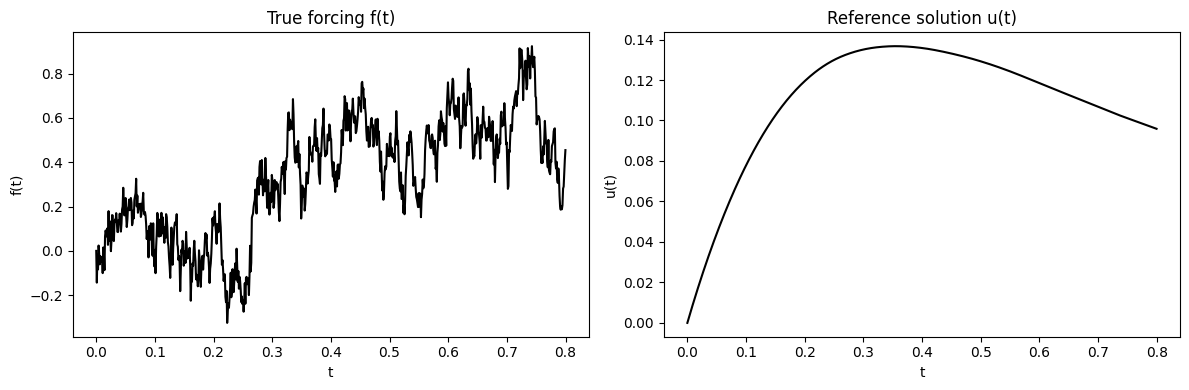

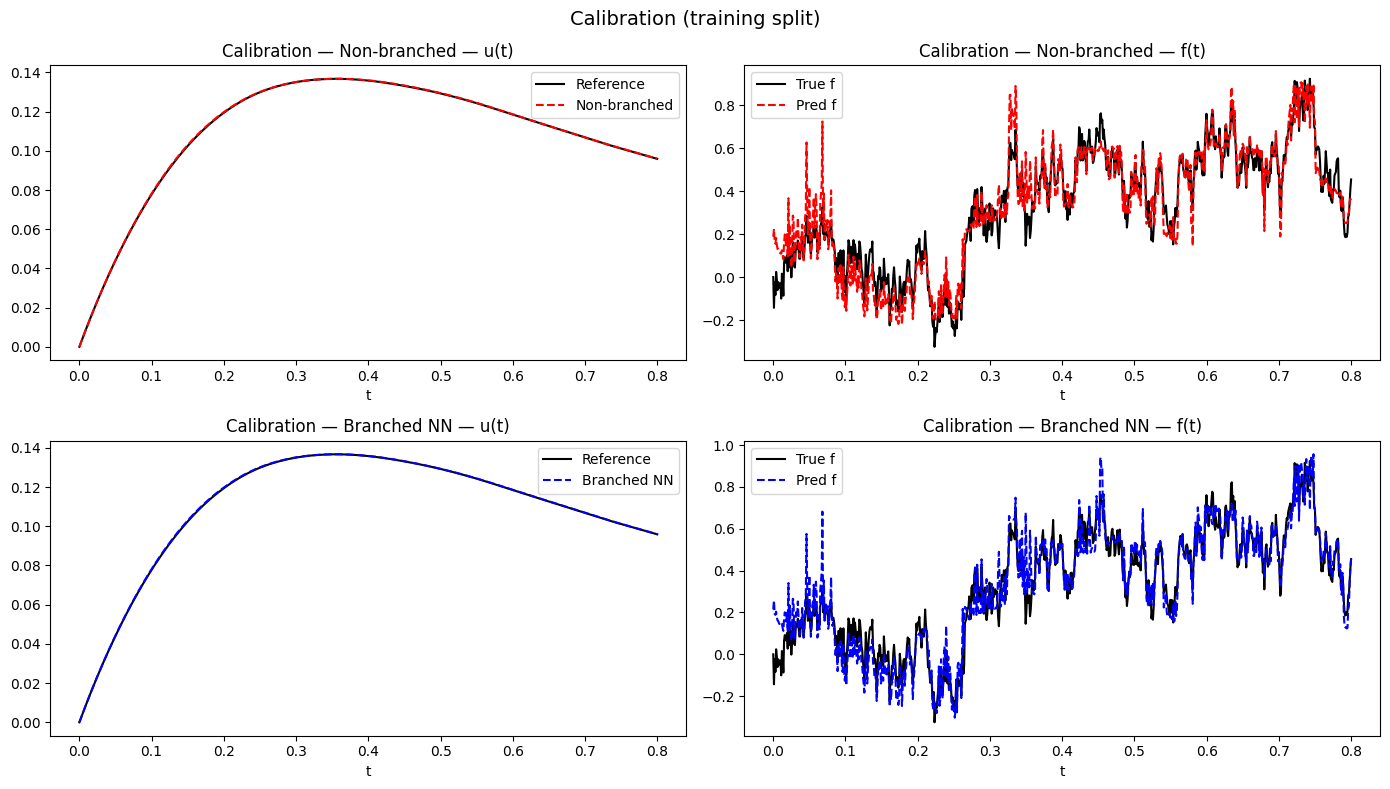

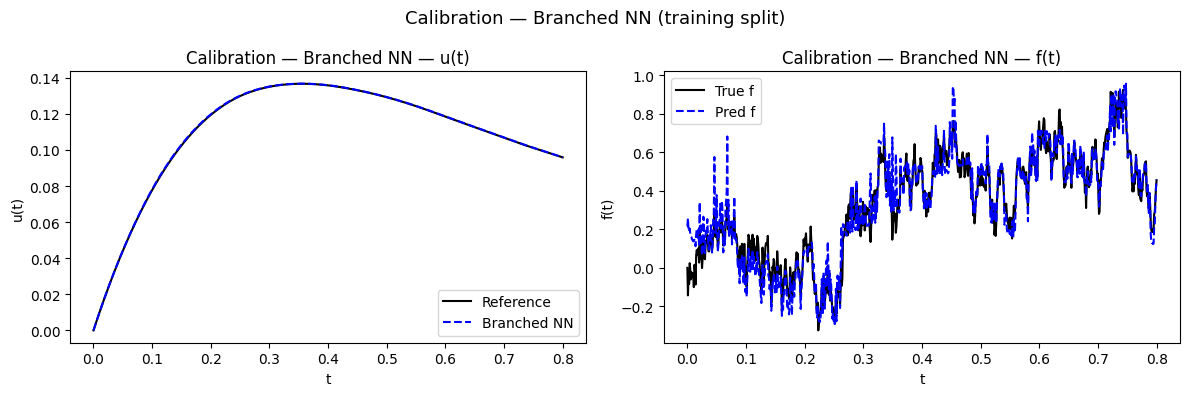

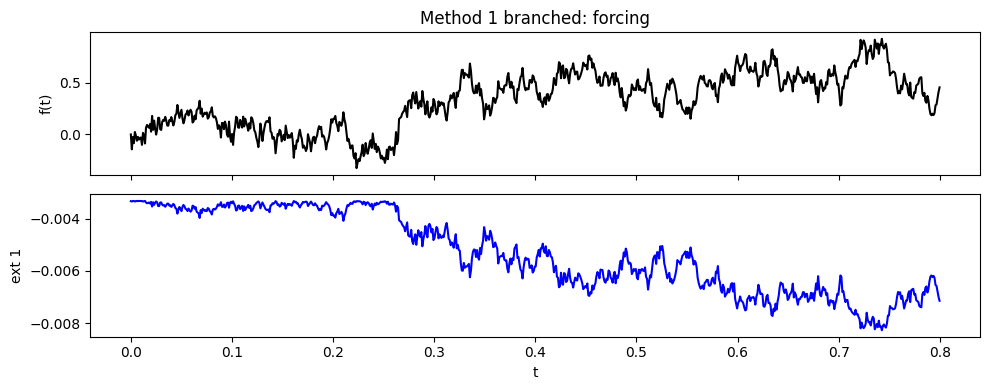

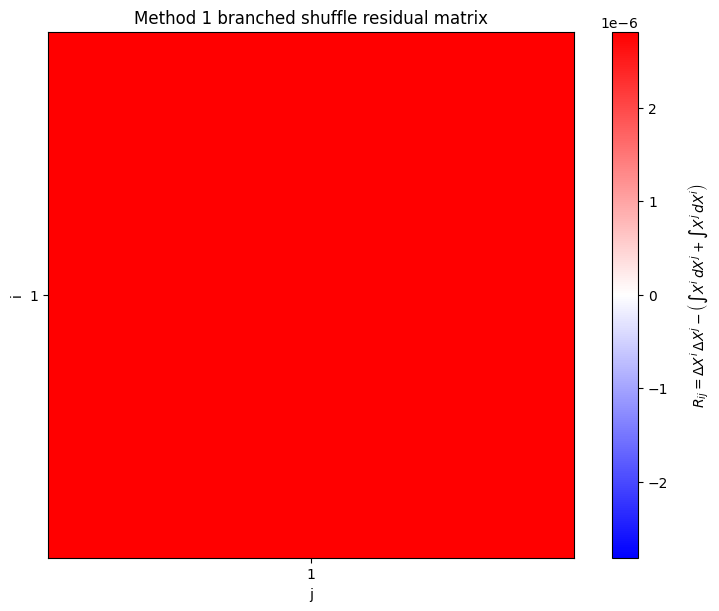

In [10]:
# ── Calibration plots ─────────────────────────────────────────────────────────

plot_reference_forcing_and_solution(
    x=x_train, f_true=forcing_train, u_ref=u_ref_train
)

plot_calibration_2x2(
    x_train=x_train,
    f_train=forcing_train,
    u_ref_train=u_ref_train,
    u_nb=u_nb_m1,
    f_pred_nb=f_pred_nb_m1,
    u_sig=u_sig_m1,
    f_pred_sig=f_pred_sig_m1,
)

plot_calibration_branched_1x2(
    x_train=x_train,
    f_train=forcing_train,
    u_ref_train=u_ref_train,
    u_sig=u_sig_m1,
    f_pred_sig=f_pred_sig_m1,
)

plot_learned_extensions(
    x=x_train,
    f_true=forcing_train,
    X_ext=path_ext_m1(torch.stack([x_train, forcing_train], dim=1)).detach(),
    title_prefix="Method 1 branched"
)

plot_shuffle_residual_matrix(
    x=x_train,
    f_true=forcing_train,
    path_ext=path_ext_m1,
    title="Method 1 branched shuffle residual matrix"
)

# Testing with retrain

In [11]:
print("\nRunning TESTING routines on train/test split...\n")

forcing_test = forcing[N_train:]

# ── Test: Non-branched ──
print("testing non-branched, method 1")
u_test_nb_m1, f_test_pred_nb_m1 = test_nonbranched_method1(
    x_train=x_train,
    x_test=x_test,
    f_train=forcing_train,
    f_test=forcing_test,
    k1=k1,
    k2=k2,
    k3=k3,
    ua=ya,
    upa=ypa,
    depth=SIG_DEPTH,
    rbf_sigma=rbf_sigma,
    beta_opt_method=BETA_OPTIMIZATION_METHOD,
    beta_iterations=BETA_MAX_ITERATIONS,
    kernel_type=KERNEL_TYPE,
    norm_scheme=NORM_SCHEME,
    norm_kwargs=NORM_KWARGS,
    retrain_every=RETRAIN_EVERY,
)

# ── Test: Branched NN ──
print("testing branched NN, method 1")
u_test_sig_m1, f_test_pred_sig_m1 = test_branched_NN_method1(
    x_train=x_train,
    x_test=x_test,
    f_train=forcing_train,
    f_test=forcing_test,
    k1=k1,
    k2=k2,
    k3=k3,
    ua=ya,
    upa=ypa,
    depth=SIG_DEPTH,
    rbf_sigma=rbf_sigma,
    pathextension=path_ext_m1,
    beta_opt_method=BETA_OPTIMIZATION_METHOD,
    beta_iterations=BETA_MAX_ITERATIONS,
    kernel_type=KERNEL_TYPE,
    norm_scheme=NORM_SCHEME,
    norm_kwargs=NORM_KWARGS,
    retrain_every=RETRAIN_EVERY,
)


Running TESTING routines on train/test split...

testing non-branched, method 1
final forcing loss (train+test, last beta): 6.088e-03
testing branched NN, method 1
final forcing loss (train+test, last beta): 5.500e-03


In [12]:
print("\nsolving ivp reference (full grid)")
x_ref_full, u_ref_full = solve_duffing_ivp(
    x_grid=x,
    forcing_torch=forcing,
    a=float(x[0]), b=float(x[-1]),
    ya=ya, ypa=ypa,
    k1=k1, k2=k2, k3=k3
)


# === Build full-path predictions by concatenating training + testing outputs ===
u_nb_m1_full       = torch.cat([u_nb_m1,  u_test_nb_m1[N_train:]],  dim=0)
f_pred_nb_m1_full  = torch.cat([f_pred_nb_m1,  f_test_pred_nb_m1[N_train:]],  dim=0)

u_sig_m1_full      = torch.cat([u_sig_m1,  u_test_sig_m1[N_train:]],  dim=0)
f_pred_sig_m1_full = torch.cat([f_pred_sig_m1, f_test_pred_sig_m1[N_train:]], dim=0)


# === Compare and Print Results (FULL train+test) ===
print("\nComparing variants on FULL path (train+test): non-branched, branched | method 1")

print("\n--- Method 1 (FULL) ---")
print_variant_errors("Non-branched", u_nb_m1_full,  f_pred_nb_m1_full,  u_ref_full, forcing, x)
print_variant_errors("Branched    ", u_sig_m1_full, f_pred_sig_m1_full, u_ref_full, forcing, x)


# ── Method 1: % improvement vs non-branched baseline (FULL) ──
nb_m1_full  = get_errors(u_nb_m1_full,  f_pred_nb_m1_full,  u_ref_full, forcing)
sig_m1_full = get_errors(u_sig_m1_full, f_pred_sig_m1_full, u_ref_full, forcing)

print("\n--- Method 1 (FULL): % improvement vs Non-branched (positive = better) ---")
print("  [Non-branched]  (baseline)")
print_pct_improvement("Branched    ", sig_m1_full, nb_m1_full)


# === Compare and Print Results (TEST portion only) ===
u_ref_test   = u_ref_full[N_train:]
forcing_test = forcing[N_train:]

u_nb_m1_test       = u_nb_m1_full[N_train:]
f_pred_nb_m1_test  = f_pred_nb_m1_full[N_train:]
u_sig_m1_test      = u_sig_m1_full[N_train:]
f_pred_sig_m1_test = f_pred_sig_m1_full[N_train:]

print("\nComparing variants on TEST ONLY: non-branched, branched | method 1")

print("\n--- Method 1 (TEST ONLY) ---")
print_variant_errors("Non-branched", u_nb_m1_test,  f_pred_nb_m1_test,  u_ref_test, forcing_test, x_test)
print_variant_errors("Branched    ", u_sig_m1_test, f_pred_sig_m1_test, u_ref_test, forcing_test, x_test)


# ── Method 1: % improvement vs non-branched baseline (TEST) ──
nb_m1_test  = get_errors(u_nb_m1_test,  f_pred_nb_m1_test,  u_ref_test, forcing_test)
sig_m1_test = get_errors(u_sig_m1_test, f_pred_sig_m1_test, u_ref_test, forcing_test)

print("\n--- Method 1 (TEST ONLY): % improvement vs Non-branched (positive = better) ---")
print("  [Non-branched]  (baseline)")
print_pct_improvement("Branched    ", sig_m1_test, nb_m1_test)


solving ivp reference (full grid)

Comparing variants on FULL path (train+test): non-branched, branched | method 1

--- Method 1 (FULL) ---
  [Non-branched]  MSE(u)=3.381e-08  RelMSE(u)=2.861e-06  MSE(f)=6.088e-03  RelMSE(f)=3.947e-02
  [Branched    ]  MSE(u)=3.186e-08  RelMSE(u)=2.695e-06  MSE(f)=5.500e-03  RelMSE(f)=3.566e-02

--- Method 1 (FULL): % improvement vs Non-branched (positive = better) ---
  [Non-branched]  (baseline)
  [Branched    ]  MSE(u)=+5.8%  RelMSE(u)=+5.8%  MSE(f)=+9.7%  RelMSE(f)=+9.7%

Comparing variants on TEST ONLY: non-branched, branched | method 1

--- Method 1 (TEST ONLY) ---
  [Non-branched]  MSE(u)=4.684e-10  RelMSE(u)=6.539e-08  MSE(f)=3.536e-03  RelMSE(f)=7.057e-02
  [Branched    ]  MSE(u)=6.362e-10  RelMSE(u)=8.880e-08  MSE(f)=3.931e-03  RelMSE(f)=7.845e-02

--- Method 1 (TEST ONLY): % improvement vs Non-branched (positive = better) ---
  [Non-branched]  (baseline)
  [Branched    ]  MSE(u)=-35.7%  RelMSE(u)=-35.8%  MSE(f)=-11.2%  RelMSE(f)=-11.2%


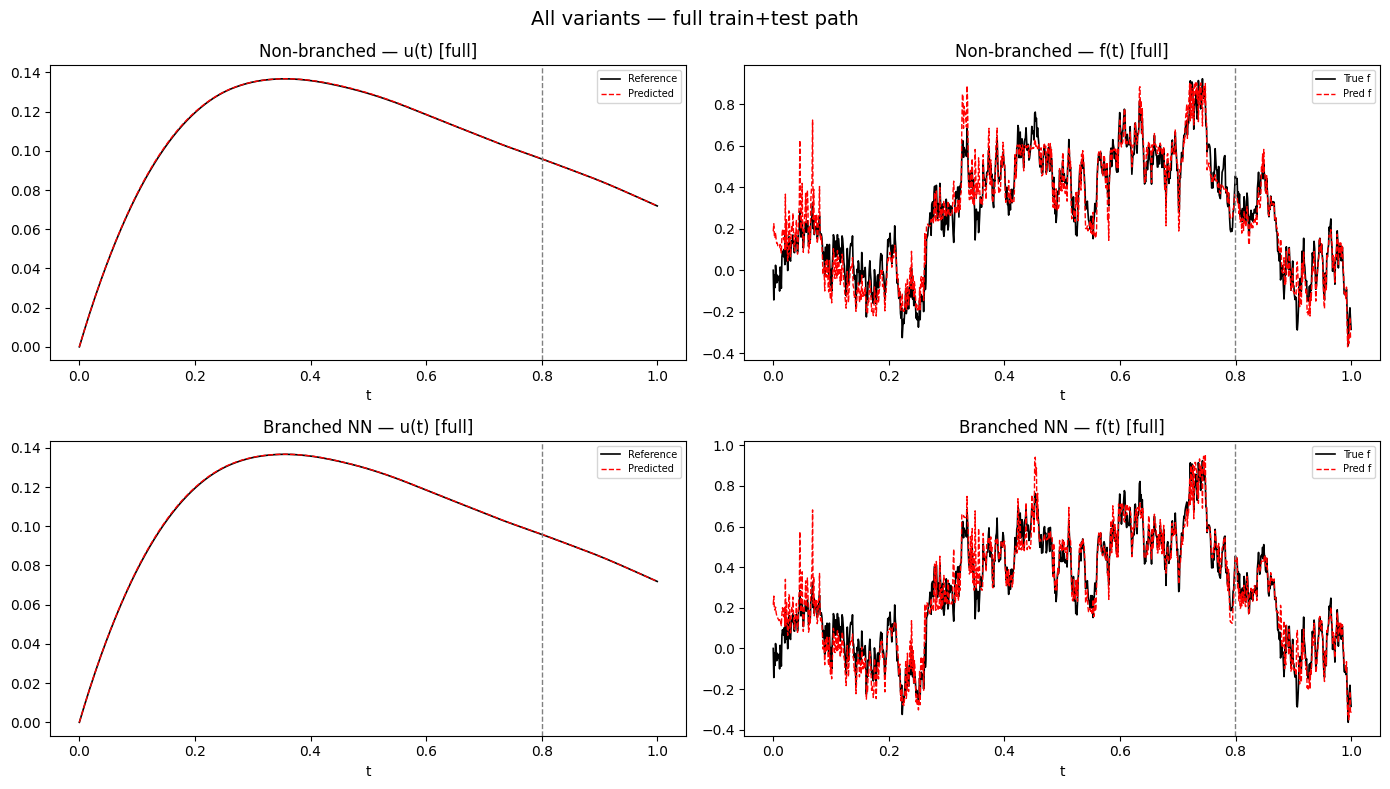

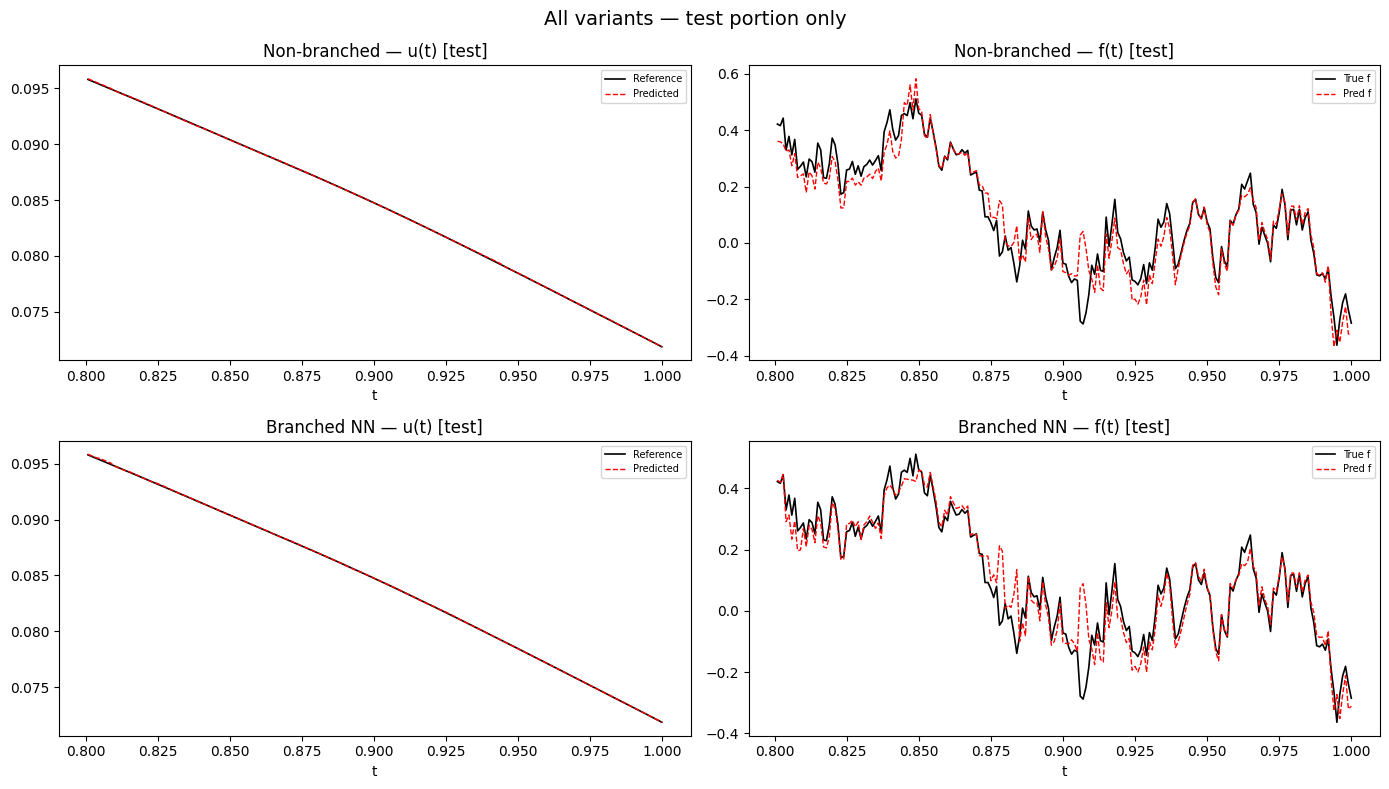

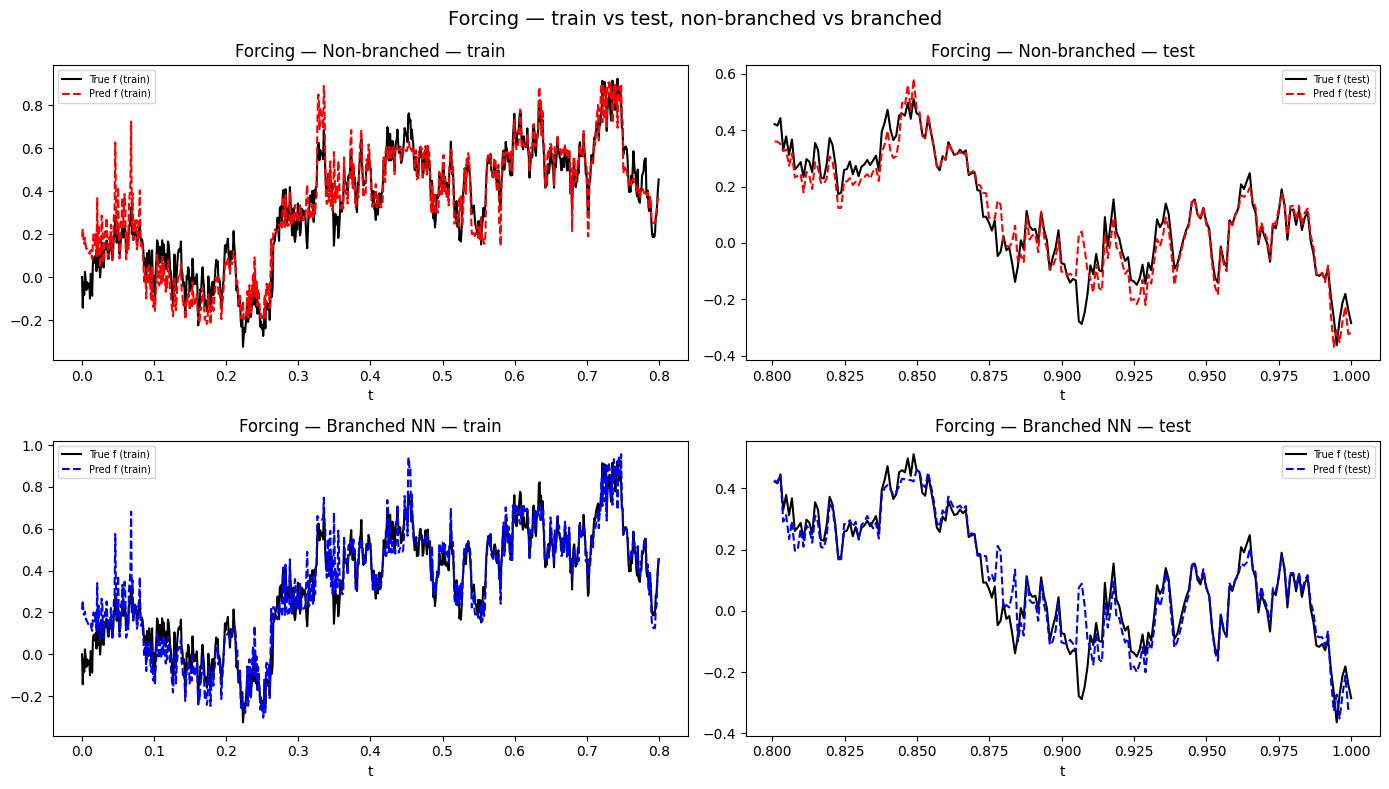

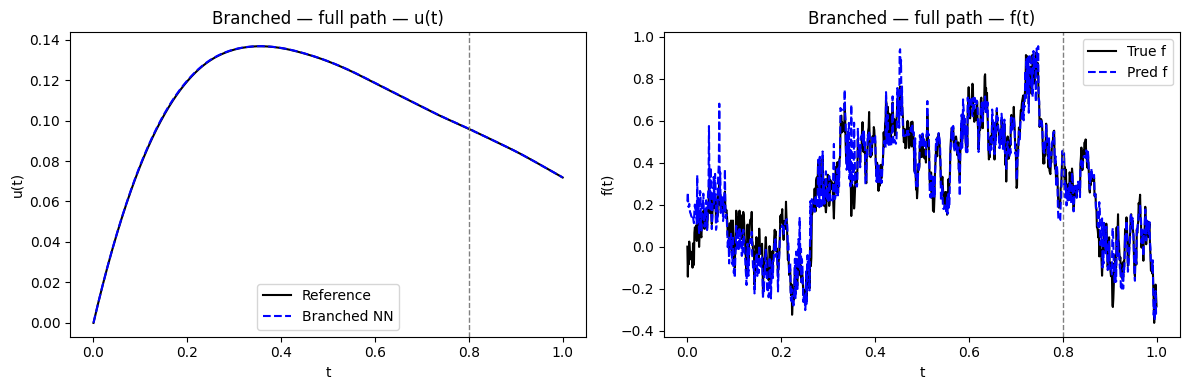

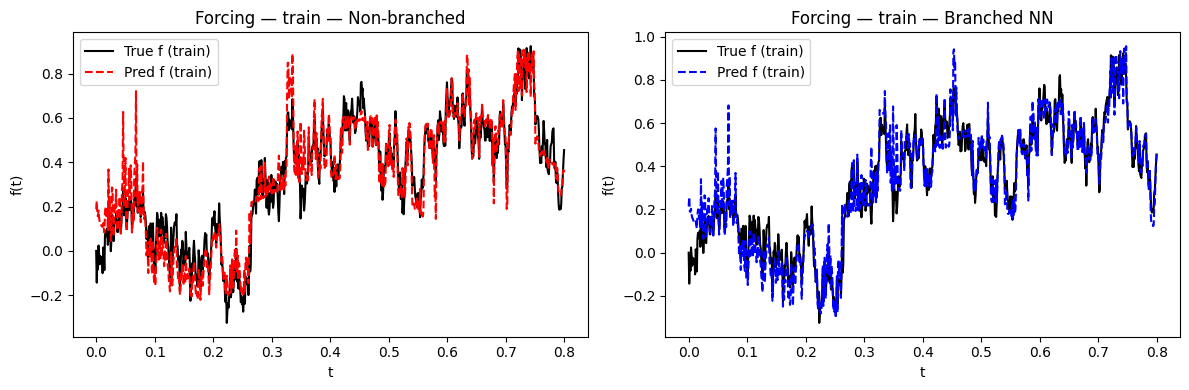

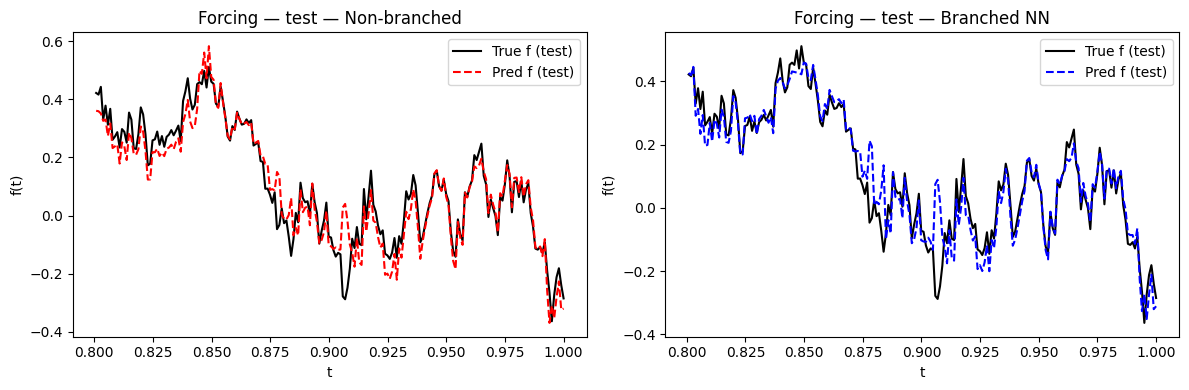

In [13]:
# === Plots: FULL train+test and TEST only ===

# 1) Full path: non-branched and branched, Method 1 only
plot_all_variants_full_train_test(
    x_full=x,
    f_true_full=forcing,
    u_ref_full=u_ref_full,
    u_nb_m1_full=u_nb_m1_full,
    f_pred_nb_m1_full=f_pred_nb_m1_full,
    u_sig_m1_full=u_sig_m1_full,
    f_pred_sig_m1_full=f_pred_sig_m1_full,
    N_train=N_train,
)

# 2) Test portion only: non-branched and branched, Method 1 only
plot_all_variants_test_only(
    x_test=x_test,
    u_ref_full=u_ref_full,
    f_true_full=forcing,
    u_nb_m1_full=u_nb_m1_full,
    f_pred_nb_m1_full=f_pred_nb_m1_full,
    u_sig_m1_full=u_sig_m1_full,
    f_pred_sig_m1_full=f_pred_sig_m1_full,
    N_train=N_train,
)

# 3) New: 2×2 forcing-only, train vs test, non-branched vs branched
plot_forcing_train_test_2x2(
    x_full=x,
    f_true_full=forcing,
    f_pred_nb_m1_full=f_pred_nb_m1_full,
    f_pred_sig_m1_full=f_pred_sig_m1_full,
    N_train=N_train,
)

# 4) New: 1×2 full path (branched only), with vertical split
plot_branched_full_1x2(
    x_full=x,
    u_ref_full=u_ref_full,
    f_true_full=forcing,
    u_sig_m1_full=u_sig_m1_full,
    f_pred_sig_m1_full=f_pred_sig_m1_full,
    N_train=N_train,
)

# 5) New: 1×2 forcing-only, training (non-branched vs branched)
plot_forcing_train_1x2(
    x_full=x,
    f_true_full=forcing,
    f_pred_nb_m1_full=f_pred_nb_m1_full,
    f_pred_sig_m1_full=f_pred_sig_m1_full,
    N_train=N_train,
)

# 6) New: 1×2 forcing-only, testing (non-branched vs branched)
plot_forcing_test_1x2(
    x_full=x,
    f_true_full=forcing,
    f_pred_nb_m1_full=f_pred_nb_m1_full,
    f_pred_sig_m1_full=f_pred_sig_m1_full,
    N_train=N_train,
)

In [14]:
# ── SELECTION ────────────────────────────────────────────────────────────────
METRIC = "RElMSE"   # <--- change to "MSE" or "RelMSE"


# ── map already-computed get_errors() results into lookup dicts ──────────────
train_errs = {
    ("Method 1", "Non-branched"): {
        "mseu": nb_m1_full["mse_u"],
        "relu": nb_m1_full["rel_u"],
        "msef": nb_m1_full["mse_f"],
        "relf": nb_m1_full["rel_f"],
    },
    ("Method 1", "Branched"): {
        "mseu": sig_m1_full["mse_u"],
        "relu": sig_m1_full["rel_u"],
        "msef": sig_m1_full["mse_f"],
        "relf": sig_m1_full["rel_f"],
    },
}

test_errs = {
    ("Method 1", "Non-branched"): {
        "mseu": nb_m1_test["mse_u"],
        "relu": nb_m1_test["rel_u"],
        "msef": nb_m1_test["mse_f"],
        "relf": nb_m1_test["rel_f"],
    },
    ("Method 1", "Branched"): {
        "mseu": sig_m1_test["mse_u"],
        "relu": sig_m1_test["rel_u"],
        "msef": sig_m1_test["mse_f"],
        "relf": sig_m1_test["rel_f"],
    },
}


# ── metric selection ─────────────────────────────────────────────────────────
if METRIC == "MSE":
    u_col, f_col, label = "mseu", "msef", "MSE"
else:
    u_col, f_col, label = "relu", "relf", "Rel-MSE"   # was "Rel-L2"


methods  = ["Method 1"]
variants = ["Non-branched", "Branched"]





BASE_STYLES = [
    {"selector": "caption",
     "props": [("font-size", "14px"), ("font-weight", "bold"),
               ("text-align", "left"), ("padding-bottom", "6px")]},
    {"selector": "th",
     "props": [("font-size", "12px"), ("text-align", "center"),
               ("padding", "6px 12px"), ("border-bottom", "2px solid #000"),
               ("background-color", "white"), ("color", "black")]},
    {"selector": "td",
     "props": [("text-align", "right"), ("font-family", "monospace"),
               ("font-size", "12px"), ("padding", "5px 12px"),
               ("background-color", "white"), ("color", "black")]},
    {"selector": "tr",
     "props": [("background-color", "white"), ("color", "black")]},
    {"selector": "",
     "props": [("border", "1px solid #ccc"), ("background-color", "white")]},
]

def val(errs_dict, method, variant, col):
    e = errs_dict.get((method, variant), {})
    v = e.get(col, None)
    return float(v) if v is not None else float("nan")

import pandas as pd
from IPython.display import display, HTML


def show(df, caption):
    display(HTML(f"<br><b style='font-size:13px; color:black'>{caption}</b>"))
    display(
        df.style
          .format("{:.3e}")
          .set_table_styles(BASE_STYLES)
          .set_properties(**{"background-color": "white", "color": "black"})
    )



# ── Table 1: Method 1 (u only) ───────────────────────────────────────────────
t1_data = {}
for method in methods:
    for variant in variants:
        t1_data[(method, variant)] = {
            "Train": val(train_errs, method, variant, u_col),
            "Test":  val(test_errs,  method, variant, u_col),
        }

t1 = pd.DataFrame(
    {(method, variant): t1_data[(method, variant)]
     for method in methods for variant in variants}
).T
t1.index = pd.MultiIndex.from_tuples(t1.index, names=["Method", "Variant"])
show(t1, f"Method 1 — {label}(u)")


# ── Table 2: Method 1 (u and f, Test and Train) ──────────────────────────────
t2_rows = {}
for variant in variants:
    t2_rows[variant] = {
        ("Testing",  "Forcing"):  val(test_errs,  "Method 1", variant, f_col),
        ("Testing",  "Solution"): val(test_errs,  "Method 1", variant, u_col),
        ("Training", "Forcing"):  val(train_errs, "Method 1", variant, f_col),
        ("Training", "Solution"): val(train_errs, "Method 1", variant, u_col),
    }

t2 = pd.DataFrame(t2_rows).T
t2.index.name = "Variant"
t2.columns = pd.MultiIndex.from_tuples(t2.columns, names=["Split", "Target"])
show(t2, f"Method 1 — {label}")



# ── Full-interval errors (train+test) ────────────────────────────────────────
full_errs = {
    ("Method 1", "Non-branched"): {
        "mseu": nb_m1_full["mse_u"],
        "relu": nb_m1_full["rel_u"],
        "msef": nb_m1_full["mse_f"],
        "relf": nb_m1_full["rel_f"],
    },
    ("Method 1", "Branched"): {
        "mseu": sig_m1_full["mse_u"],
        "relu": sig_m1_full["rel_u"],
        "msef": sig_m1_full["mse_f"],
        "relf": sig_m1_full["rel_f"],
    },
}

# ── Table 3: Method 1 (u and f, Test / Train / Full) ────────────────────────
t3_rows = {}
for variant in variants:
    t3_rows[variant] = {
        ("Testing",  "Forcing"):  val(test_errs,  "Method 1", variant, f_col),
        ("Testing",  "Solution"): val(test_errs,  "Method 1", variant, u_col),
        ("Training", "Forcing"):  val(train_errs, "Method 1", variant, f_col),
        ("Training", "Solution"): val(train_errs, "Method 1", variant, u_col),
        ("Full",     "Forcing"):  val(full_errs,  "Method 1", variant, f_col),
        ("Full",     "Solution"): val(full_errs,  "Method 1", variant, u_col),
    }

t3 = pd.DataFrame(t3_rows).T
t3.index.name = "Variant"
# enforce column order explicitly so Full is last
t3_cols = [
    ("Testing",  "Forcing"),
    ("Testing",  "Solution"),
    ("Training", "Forcing"),
    ("Training", "Solution"),
    ("Full",     "Forcing"),
    ("Full",     "Solution"),
]
t3.columns = pd.MultiIndex.from_tuples(t3_cols, names=["Split", "Target"])

show(t3, f"Method 1 — {label} (Test / Train / Full)")